## Instructions

- Download and import the Data Science Job Salary dataset here.
- Identify and differentiate between quantitative and qualitative data within the dataset.
- Preprocess the data by handling missing values and removing duplicates if needed.
- Perform a group-wise analysis of the experience_level column, calculating the mean and median salaries for each group using Pandas’ .groupby.
- Utilize Pandas’ integration with Matplotlib to create a bar chart visualizing the average salaries for each experience level. Ensure the chart includes appropriate labels, a title, and a color scheme that enhances readability.

In [118]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =========== BASIC WORKFLOW ===========
df = pd.read_csv('data/ds_salaries.csv')

df.head()

,Unnamed: 0,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,0,2020,MI,FT,Data Scientist,70000,EUR,79833,DE,0,DE,L
1,1,2020,SE,FT,Machine Learning Scientist,260000,USD,260000,JP,0,JP,S
2,2,2020,SE,FT,Big Data Engineer,85000,GBP,109024,GB,50,GB,M
3,3,2020,MI,FT,Product Data Analyst,20000,USD,20000,HN,0,HN,S
4,4,2020,SE,FT,Machine Learning Engineer,150000,USD,150000,US,50,US,L


In [119]:
df.shape

(607, 12)

In [120]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 607 entries, 0 to 606
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   Unnamed: 0          607 non-null    int64
 1   work_year           607 non-null    int64
 2   experience_level    607 non-null    str  
 3   employment_type     607 non-null    str  
 4   job_title           607 non-null    str  
 5   salary              607 non-null    int64
 6   salary_currency     607 non-null    str  
 7   salary_in_usd       607 non-null    int64
 8   employee_residence  607 non-null    str  
 9   remote_ratio        607 non-null    int64
 10  company_location    607 non-null    str  
 11  company_size        607 non-null    str  
dtypes: int64(5), str(7)
memory usage: 57.0 KB


In [121]:
df.describe()

,Unnamed: 0,work_year,salary,salary_in_usd,remote_ratio
count,607.000000,607.000000,6.070000e+02,607.000000,607.00000
mean,303.000000,2021.405272,3.240001e+05,112297.869852,70.92257
std,175.370085,0.692133,1.544357e+06,70957.259411,40.70913
min,0.000000,2020.000000,4.000000e+03,2859.000000,0.00000
25%,151.500000,2021.000000,7.000000e+04,62726.000000,50.00000
50%,303.000000,2022.000000,1.150000e+05,101570.000000,100.00000
75%,454.500000,2022.000000,1.650000e+05,150000.000000,100.00000
max,606.000000,2022.000000,3.040000e+07,600000.000000,100.00000


### Qualitative data:

`work_year`, `experience_level`, `employment_type`, `job_title`, `salary_currency`, `employee_residence`, `company_location`, `company_size`

### Quantitative data:

`salary`, `salary_in_usd`, `remote_ratio`

In [122]:
# ============ PREPROCESSING DATA ============

# Drop irrelevant column 'Unnamed: 0
df = df.drop(columns=["Unnamed: 0"])

# Check if there are any missing values
print('\nAre there any missing values?\n')
missing_counts = df.isnull().sum().to_frame(name='missing_count')
print(missing_counts)


Are there any missing values?

                    missing_count
work_year                       0
experience_level                0
employment_type                 0
job_title                       0
salary                          0
salary_currency                 0
salary_in_usd                   0
employee_residence              0
remote_ratio                    0
company_location                0
company_size                    0


In [123]:
duplicated_rows = df.duplicated().sum()
print(f'Number of duplicated rows: {duplicated_rows}.')

# Rows that were identical across all features were removed, as they likely represent duplicate records rather than distinct individuals.

df = df.drop_duplicates()
duplicated_rows_updated = df.duplicated().sum()
print(f'Number of duplicated rows after drop: {duplicated_rows_updated}.')


Number of duplicated rows: 42.
Number of duplicated rows after drop: 0.


In [124]:
# Create a GroupBy DataFrame for the 'experience_level' groups
# Calculate mean and median for 'salary_in_usd' for each group
experience_salary = df.groupby("experience_level")["salary_in_usd"].agg(
    mean_salary='mean',
    median_salary='median'
)

print(experience_salary.round(2))

                  mean_salary  median_salary
experience_level                            
EN                   61643.32        56500.0
EX                  199392.04       171437.5
MI                   87793.00        76940.0
SE                  138374.88       135000.0


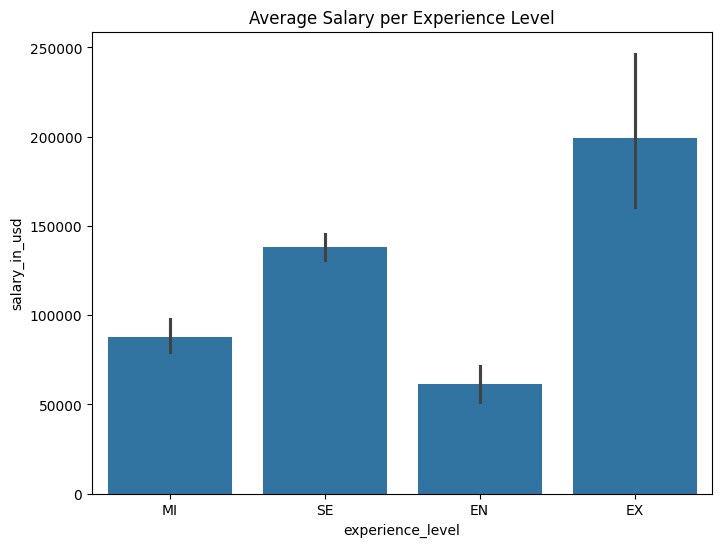

In [125]:
# Make barplot of avarage salary for each experience level
fig, axs = plt.subplots(figsize=(8, 6))
axs = sns.barplot(x="experience_level", y="salary_in_usd", data=df)
plt.title("Average Salary per Experience Level")
plt.show()